In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy

In [2]:
# Import Libraries


import os
import io
import zipfile
import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    mean_squared_error, mean_absolute_error,
    confusion_matrix, classification_report
)
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.style.use("seaborn-v0_8-whitegrid")

print("\u2714  All libraries imported successfully.")

✔  All libraries imported successfully.


In [3]:
# Download dataset automatically
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
DATA_DIR = "ml-latest-small"

if not os.path.exists(DATA_DIR):
    print("Downloading MovieLens dataset ...")
    r = requests.get(DATA_URL)
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(".")
    print("\u2714  Download complete.")
else:
    print("\u2714  Dataset already present \u2013 skipping download.")

✔  Dataset already present – skipping download.


In [4]:
import pandas as pd

In [5]:
# Load CSV Files

ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")
movies  = pd.read_csv(f"{DATA_DIR}/movies.csv")
tags    = pd.read_csv(f"{DATA_DIR}/tags.csv")

print(f"ratings.csv  \u2192 {ratings.shape[0]:,} rows \u00d7 {ratings.shape[1]} cols")
print(f"movies.csv   \u2192 {movies.shape[0]:,} rows \u00d7 {movies.shape[1]} cols")
print(f"tags.csv     \u2192 {tags.shape[0]:,} rows \u00d7 {tags.shape[1]} cols")

ratings.csv  → 100,836 rows × 4 cols
movies.csv   → 9,742 rows × 3 cols
tags.csv     → 3,683 rows × 4 cols


In [6]:
# EDA: Descriptive Statistics


print("  EXPLORATORY DATA ANALYSIS \u2013 describe / info / isnull")


print("\n\u25b6  ratings.describe()")
print(ratings.describe().to_string())

print("\n\u25b6  movies.describe(include='all')")
print(movies.describe(include="all").to_string())

  EXPLORATORY DATA ANALYSIS – describe / info / isnull

▶  ratings.describe()
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09

▶  movies.describe(include='all')
              movieId        title genres
count     9742.000000         9742   9742
unique            NaN         9737    951
top               NaN  Emma (1996)  Drama
freq              NaN            2   1053
mean     42200.353623          NaN    NaN
std      52160.494854          NaN    NaN
min     

In [7]:
#  EDA: Data Info AND Null Value Check


print("\u25b6  ratings.info()")
ratings.info()

print("\n\u25b6  movies.info()")
movies.info()

print("\u25b6  ratings.isnull().sum()")
print(ratings.isnull().sum())

print("\n\u25b6  movies.isnull().sum()")
print(movies.isnull().sum())

print("\n\u25b6  tags.isnull().sum()")
print(tags.isnull().sum())

▶  ratings.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

▶  movies.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
▶  ratings.isnull().sum()
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

▶  movies.isnull().sum()
movieId    0
title      0
genres     0
dtype: int64

▶  tags.isnull().sum()
userId       0

In [8]:
#. Data Preprocessing

print("  DATA PREPROCESSING")

# Drop duplicates
ratings.drop_duplicates(inplace=True)
movies.drop_duplicates(inplace=True)

# Parse genres
movies["genres_list"] = movies["genres"].str.split("|")

# Merge ratings + movie titles
data = ratings.merge(movies[["movieId", "title", "genres"]], on="movieId")

# Filter: keep users with >= 20 ratings & movies with >= 10 ratings
user_counts  = data["userId"].value_counts()
movie_counts = data["movieId"].value_counts()
data = data[
    data["userId"].isin(user_counts[user_counts >= 20].index) &
    data["movieId"].isin(movie_counts[movie_counts >= 10].index)
]

print(f"  Filtered dataset \u2192 {data.shape[0]:,} interactions")
print(f"  Unique users     \u2192 {data['userId'].nunique():,}")
print(f"  Unique movies    \u2192 {data['movieId'].nunique():,}")
print(f"  Rating range     \u2192 {data['rating'].min()} \u2013 {data['rating'].max()}")

  DATA PREPROCESSING
  Filtered dataset → 81,116 interactions
  Unique users     → 610
  Unique movies    → 2,269
  Rating range     → 0.5 – 5.0


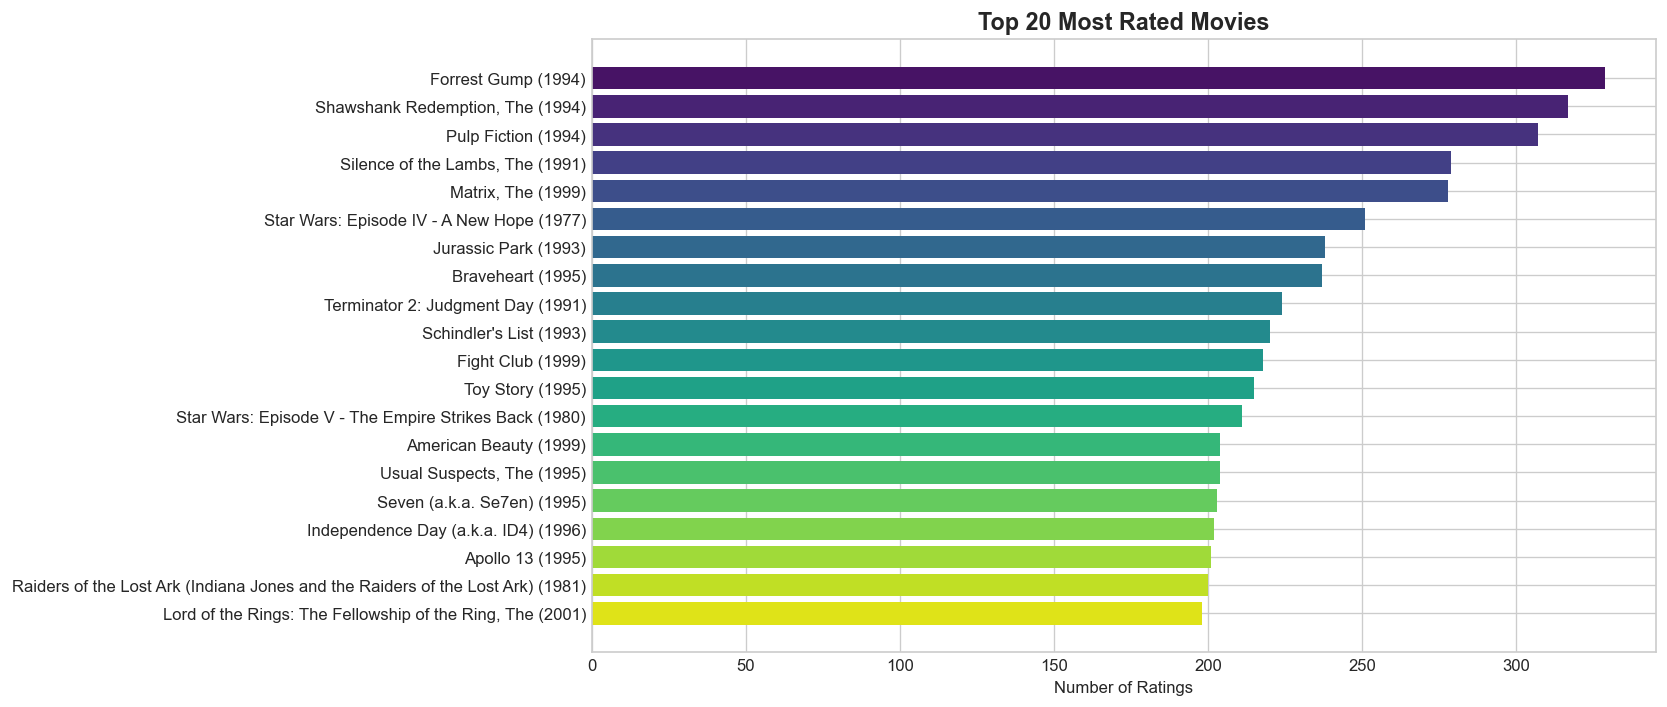

In [9]:
# Graph: Top 20 Most Rated Movies

fig, ax = plt.subplots(figsize=(14, 6))
top20 = (data.groupby("title")["rating"]
           .count()
           .nlargest(20)
           .reset_index()
           .rename(columns={"rating": "count"}))
ax.barh(top20["title"], top20["count"],
        color=sns.color_palette("viridis", 20))
ax.set_title("Top 20 Most Rated Movies", fontweight="bold", fontsize=14)
ax.set_xlabel("Number of Ratings")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


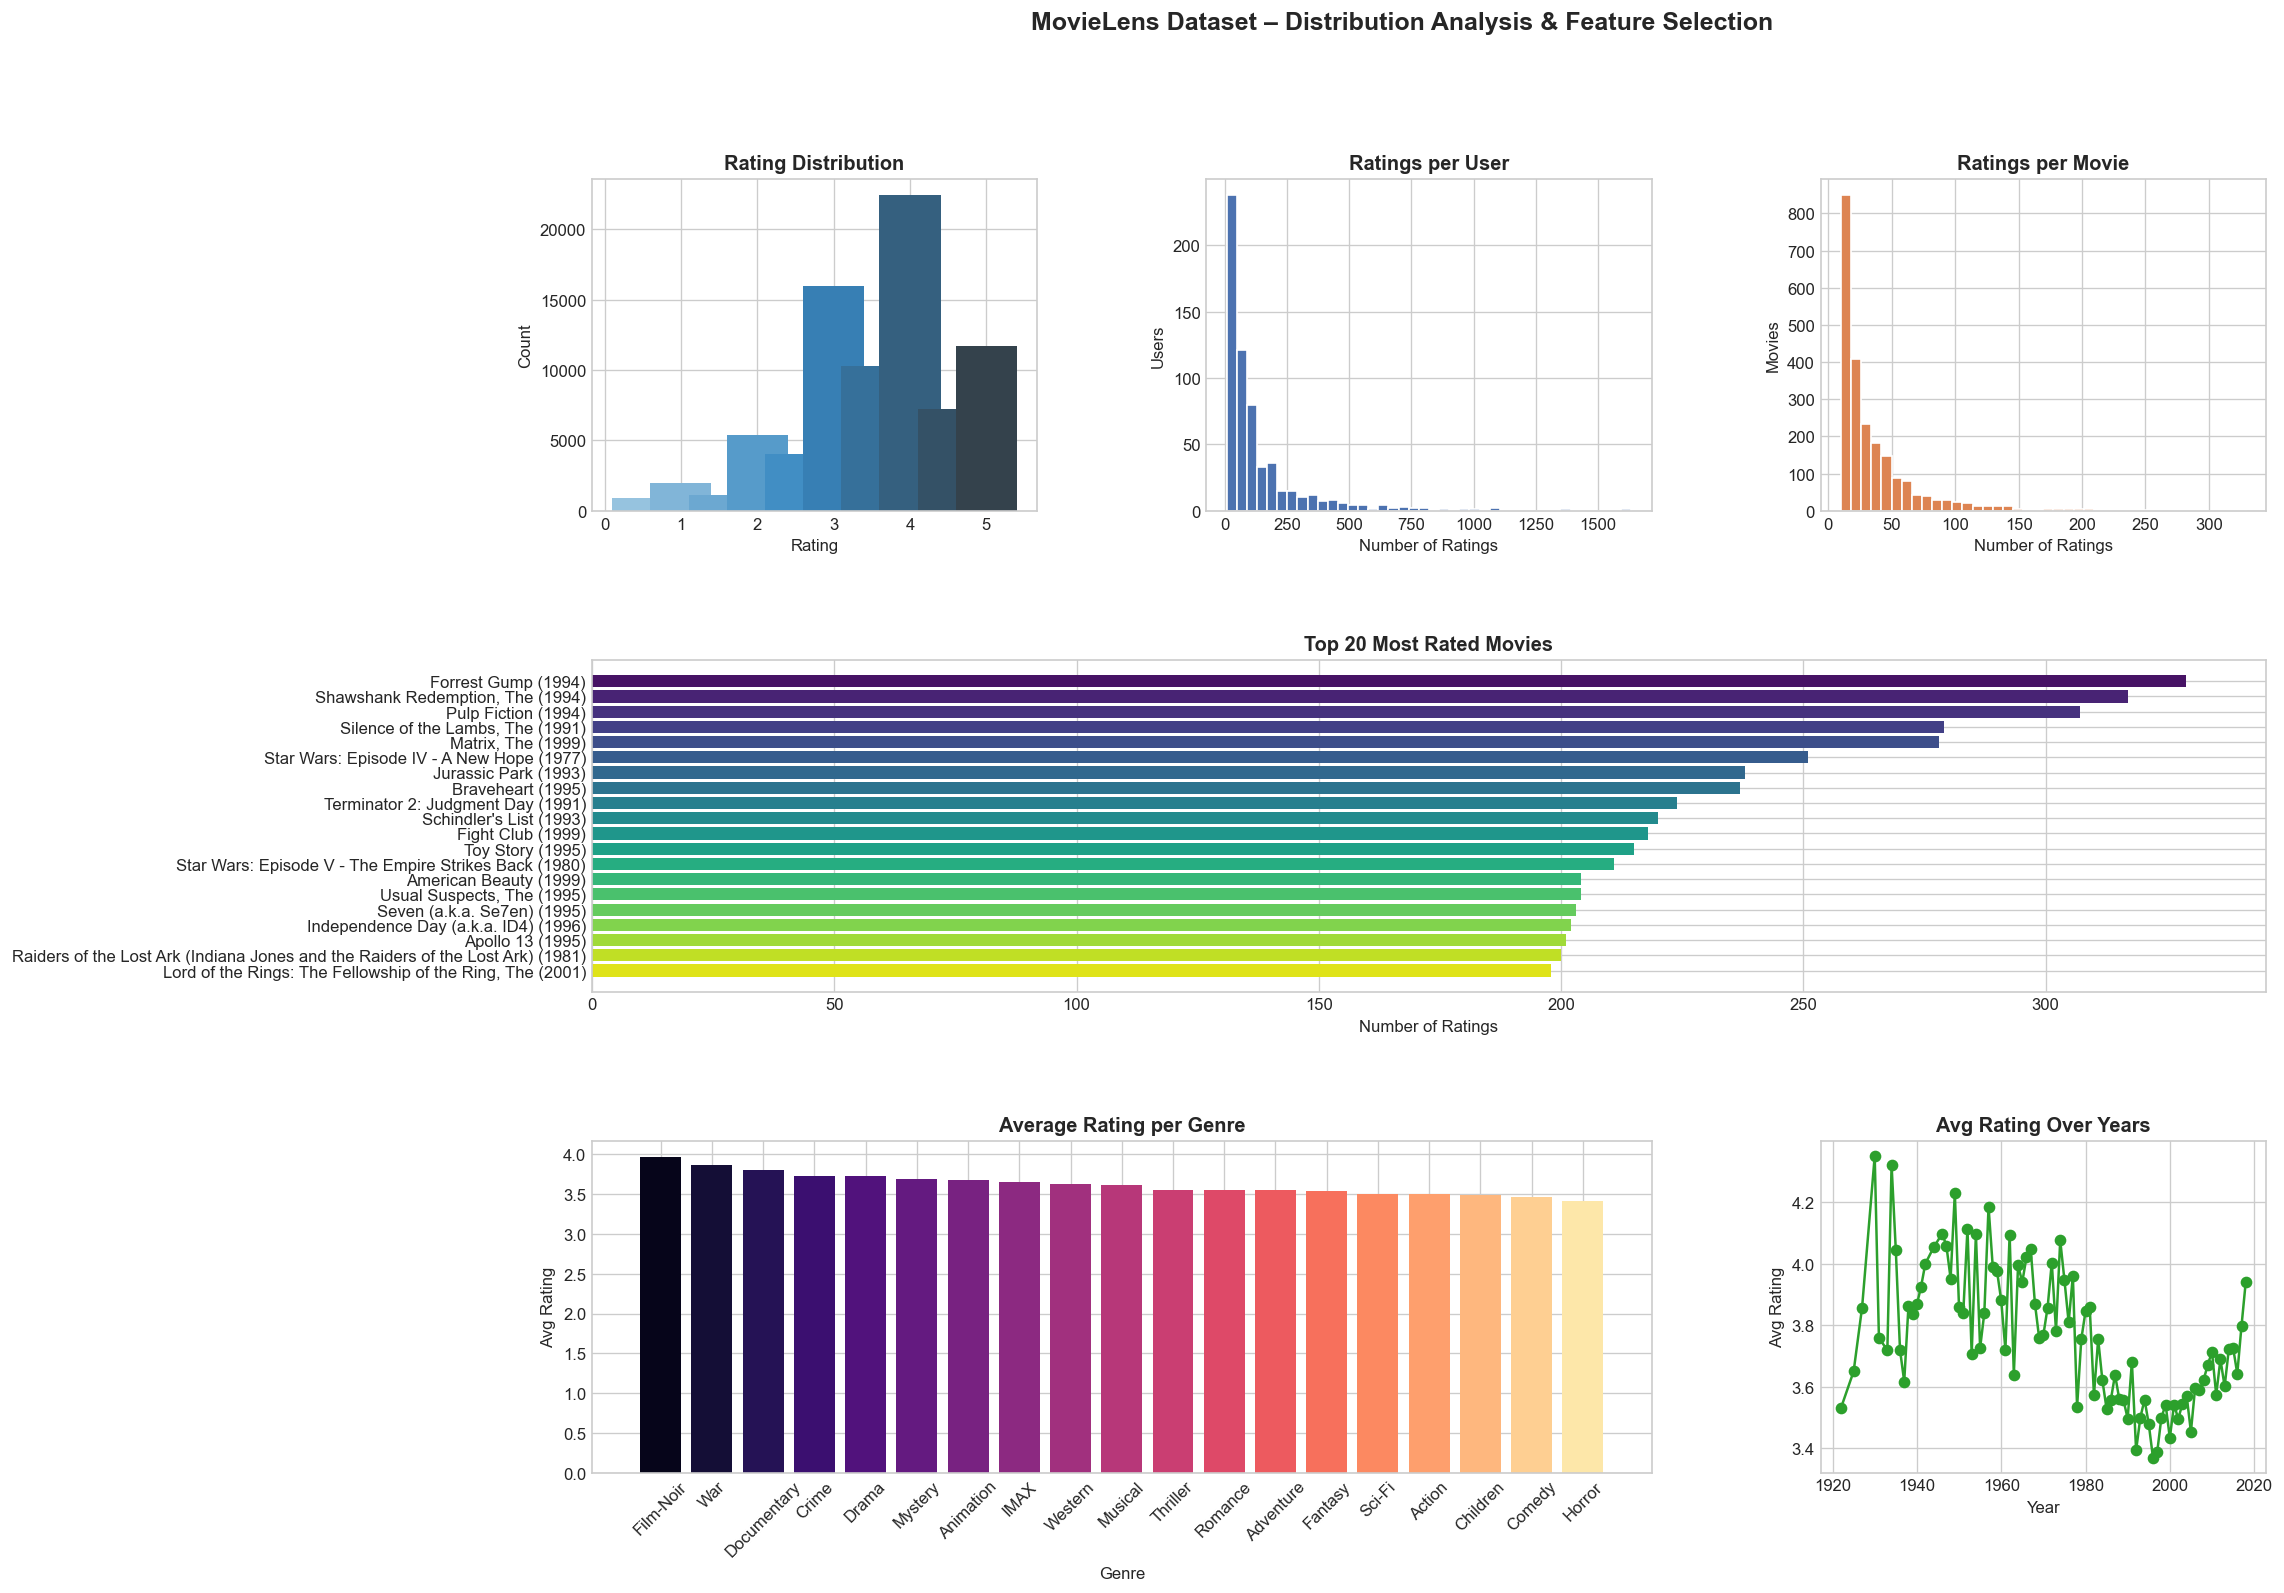

✔  Saved → distribution_analysis.png


In [10]:
#  Graph:Combined Distribution Analysis
fig = plt.figure(figsize=(18, 14))
fig.suptitle("MovieLens Dataset – Distribution Analysis & Feature Selection",
             fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# (a) Rating distribution
ax1 = fig.add_subplot(gs[0, 0])
rating_counts = data["rating"].value_counts().sort_index()
ax1.bar(rating_counts.index, rating_counts.values,
        color=sns.color_palette("Blues_d", len(rating_counts)))
ax1.set_title("Rating Distribution", fontweight="bold")
ax1.set_xlabel("Rating"); ax1.set_ylabel("Count")

# (b) Ratings per user
ax2 = fig.add_subplot(gs[0, 1])
user_rating_counts = data.groupby("userId").size()
ax2.hist(user_rating_counts, bins=40, color="#4C72B0", edgecolor="white")
ax2.set_title("Ratings per User", fontweight="bold")
ax2.set_xlabel("Number of Ratings"); ax2.set_ylabel("Users")

# (c) Ratings per movie
ax3 = fig.add_subplot(gs[0, 2])
movie_rating_counts = data.groupby("movieId").size()
ax3.hist(movie_rating_counts, bins=40, color="#DD8452", edgecolor="white")
ax3.set_title("Ratings per Movie", fontweight="bold")
ax3.set_xlabel("Number of Ratings"); ax3.set_ylabel("Movies")

# (d) Top-20 most rated movies
ax4 = fig.add_subplot(gs[1, :])
top20 = (data.groupby("title")["rating"]
           .count().nlargest(20).reset_index()
           .rename(columns={"rating": "count"}))
ax4.barh(top20["title"], top20["count"],
         color=sns.color_palette("viridis", 20))
ax4.set_title("Top 20 Most Rated Movies", fontweight="bold")
ax4.set_xlabel("Number of Ratings"); ax4.invert_yaxis()

# (e) Average rating per genre
ax5 = fig.add_subplot(gs[2, 0:2])
genre_df = data.copy()
genre_df["genres_split"] = genre_df["genres"].str.split("|")
genre_exploded = genre_df.explode("genres_split")
genre_avg = (genre_exploded.groupby("genres_split")["rating"]
             .mean().sort_values(ascending=False))
ax5.bar(genre_avg.index, genre_avg.values,
        color=sns.color_palette("magma", len(genre_avg)))
ax5.set_title("Average Rating per Genre", fontweight="bold")
ax5.set_xlabel("Genre"); ax5.set_ylabel("Avg Rating")
ax5.tick_params(axis="x", rotation=45)

# (f) Rating over time
import re
data["year"] = data["title"].str.extract(r"\((\d{4})\)").astype(float)
ax6 = fig.add_subplot(gs[2, 2])
yearly = data.groupby("year")["rating"].mean()
ax6.plot(yearly.index, yearly.values, marker="o", color="#2ca02c")
ax6.set_title("Avg Rating Over Years", fontweight="bold")
ax6.set_xlabel("Year"); ax6.set_ylabel("Avg Rating")

plt.savefig("distribution_analysis.png", bbox_inches="tight")
plt.show()
print("✔  Saved → distribution_analysis.png")

In [11]:
# Feature Selection
print("  Selected Features for Collaborative Filtering:")
print("  \u250c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510")
print("  \u2502  userId   \u2013 identifies the user (row in user-item matrix)\u2502")
print("  \u2502  movieId  \u2013 identifies the item (col in user-item matrix)\u2502")
print("  \u2502  rating   \u2013 explicit feedback signal (1.0 \u2013 5.0)         \u2502")
print("  \u2502  title    \u2013 human-readable movie label                   \u2502")
print("  \u2502  genres   \u2013 used for genre-level evaluation              \u2502")
print("  \u2514\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2518")


  Selected Features for Collaborative Filtering:
  ┌──────────────────────────────────────────────────────────┐
  │  userId   – identifies the user (row in user-item matrix)│
  │  movieId  – identifies the item (col in user-item matrix)│
  │  rating   – explicit feedback signal (1.0 – 5.0)         │
  │  title    – human-readable movie label                   │
  │  genres   – used for genre-level evaluation              │
  └──────────────────────────────────────────────────────────┘


In [12]:
# Build User-Item Matrix & Evaluation Helpers

print("  MODEL TRAINING")

# Re-encode IDs to contiguous integers
le_user  = LabelEncoder()
le_movie = LabelEncoder()
data["user_idx"]  = le_user.fit_transform(data["userId"])
data["movie_idx"] = le_movie.fit_transform(data["movieId"])

# Train / test split (80 / 20)
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

n_users  = data["user_idx"].nunique()
n_movies = data["movie_idx"].nunique()

# Build sparse matrices
def build_matrix(df, n_u, n_m):
    return csr_matrix(
        (df["rating"], (df["user_idx"], df["movie_idx"])),
        shape=(n_u, n_m)
    )

train_matrix = build_matrix(train_df, n_users, n_movies)
print(f"  Train matrix shape: {train_matrix.shape}  |  "
      f"Density: {train_matrix.nnz / (n_users * n_movies):.4%}")

# Utility: convert continuous predictions to binary relevance
RELEVANCE_THRESHOLD = 3.5   # rating >= 3.5 = "liked"

def to_binary(arr, threshold=RELEVANCE_THRESHOLD):
    return (np.array(arr) >= threshold).astype(int)

def evaluate_predictions(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    y_pred_clipped = np.clip(y_pred, 0.5, 5.0)
    y_true_bin = to_binary(y_true)
    y_pred_bin = to_binary(y_pred_clipped)
    acc    = accuracy_score(y_true_bin, y_pred_bin)
    f1     = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)

    print(f"\n  \u2500\u2500 {model_name} \u2500\u2500")
    print(f"  RMSE     : {rmse:.4f}")
    print(f"  MAE      : {mae:.4f}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print()
    print(classification_report(y_true_bin, y_pred_bin,
                                 target_names=["Not Liked", "Liked"],
                                 zero_division=0))
    return dict(model=model_name, rmse=rmse, mae=mae,
                accuracy=acc, f1=f1, recall=recall)

print("\u2714  Matrix built & helpers ready.")


  MODEL TRAINING
  Train matrix shape: (610, 2269)  |  Density: 4.6884%
✔  Matrix built & helpers ready.


In [13]:
# Model A: User-Based Collaborative Filtering (KNN)

print("  \u25ba Training User-Based CF (KNN, cosine similarity) \u2026")
user_knn = NearestNeighbors(metric="cosine", algorithm="brute",
                             n_neighbors=20, n_jobs=-1)
user_knn.fit(train_matrix)

def predict_user_based(test_df, train_matrix, model, n_neighbors=20):
    preds = []
    for _, row in test_df.iterrows():
        u = int(row["user_idx"])
        m = int(row["movie_idx"])
        user_vec = train_matrix[u]
        distances, indices = model.kneighbors(user_vec, n_neighbors=n_neighbors + 1)
        distances = distances.flatten()[1:]
        indices   = indices.flatten()[1:]
        sim_scores = 1 - distances
        neigh_ratings = train_matrix[indices, m].toarray().flatten()
        rated_mask = neigh_ratings > 0
        if rated_mask.sum() == 0:
            preds.append(train_matrix[u].data.mean() if train_matrix[u].nnz > 0 else 3.0)
        else:
            w = sim_scores[rated_mask]
            r = neigh_ratings[rated_mask]
            preds.append(float(np.dot(w, r) / (w.sum() + 1e-9)))
    return np.array(preds)

y_true_ub = test_df["rating"].values
y_pred_ub = predict_user_based(test_df.head(2000), train_matrix, user_knn)
results_ub = evaluate_predictions(y_true_ub[:2000], y_pred_ub, "User-Based CF (KNN)")


  ► Training User-Based CF (KNN, cosine similarity) …

  ── User-Based CF (KNN) ──
  RMSE     : 1.0045
  MAE      : 0.7622
  Accuracy : 0.6405
  F1 Score : 0.7040
  Recall   : 0.6701

              precision    recall  f1-score   support

   Not Liked       0.50      0.59      0.54       724
       Liked       0.74      0.67      0.70      1276

    accuracy                           0.64      2000
   macro avg       0.62      0.63      0.62      2000
weighted avg       0.66      0.64      0.65      2000



In [14]:
#  Model B: Item-Based Collaborative Filtering (KNN)

print("  \u25ba Training Item-Based CF (KNN, cosine similarity) \u2026")
item_knn = NearestNeighbors(metric="cosine", algorithm="brute",
                             n_neighbors=20, n_jobs=-1)
item_knn.fit(train_matrix.T)

def predict_item_based(test_df, train_matrix, model, n_neighbors=20):
    preds = []
    for _, row in test_df.iterrows():
        u = int(row["user_idx"])
        m = int(row["movie_idx"])
        item_vec = train_matrix.T[m]
        distances, indices = model.kneighbors(item_vec, n_neighbors=n_neighbors + 1)
        distances = distances.flatten()[1:]
        indices   = indices.flatten()[1:]
        sim_scores    = 1 - distances
        user_ratings  = train_matrix[u, indices].toarray().flatten()
        rated_mask    = user_ratings > 0
        if rated_mask.sum() == 0:
            preds.append(train_matrix[u].data.mean() if train_matrix[u].nnz > 0 else 3.0)
        else:
            w = sim_scores[rated_mask]
            r = user_ratings[rated_mask]
            preds.append(float(np.dot(w, r) / (w.sum() + 1e-9)))
    return np.array(preds)

y_true_ib = test_df["rating"].values
y_pred_ib = predict_item_based(test_df.head(2000), train_matrix, item_knn)
results_ib = evaluate_predictions(y_true_ib[:2000], y_pred_ib, "Item-Based CF (KNN)")


  ► Training Item-Based CF (KNN, cosine similarity) …

  ── Item-Based CF (KNN) ──
  RMSE     : 0.9027
  MAE      : 0.6690
  Accuracy : 0.7055
  F1 Score : 0.7632
  Recall   : 0.7437

              precision    recall  f1-score   support

   Not Liked       0.59      0.64      0.61       724
       Liked       0.78      0.74      0.76      1276

    accuracy                           0.71      2000
   macro avg       0.68      0.69      0.69      2000
weighted avg       0.71      0.71      0.71      2000



In [15]:
#  Model C: SVD Matrix Factorisation

print("  \u25ba Training SVD Matrix Factorisation (k=50) \u2026")
svd = TruncatedSVD(n_components=50, random_state=42)
U   = svd.fit_transform(train_matrix)
Vt  = svd.components_
reconstructed_svd = np.dot(U, Vt)

def predict_mf(test_df, reconstructed):
    preds = []
    for _, row in test_df.iterrows():
        u = int(row["user_idx"])
        m = int(row["movie_idx"])
        preds.append(reconstructed[u, m])
    return np.array(preds)

y_pred_svd = predict_mf(test_df.head(2000), reconstructed_svd)
results_svd = evaluate_predictions(y_true_ub[:2000], y_pred_svd, "SVD Matrix Factorisation")


  ► Training SVD Matrix Factorisation (k=50) …

  ── SVD Matrix Factorisation ──
  RMSE     : 3.0716
  MAE      : 2.8678
  Accuracy : 0.3655
  F1 Score : 0.0109
  Recall   : 0.0055

              precision    recall  f1-score   support

   Not Liked       0.36      1.00      0.53       724
       Liked       1.00      0.01      0.01      1276

    accuracy                           0.37      2000
   macro avg       0.68      0.50      0.27      2000
weighted avg       0.77      0.37      0.20      2000



In [16]:
#  Model D: NMF Matrix Factorisation

print("  \u25ba Training NMF Matrix Factorisation (k=20) \u2026")
sample_matrix = train_matrix.toarray().astype(np.float32)
nmf = NMF(n_components=20, max_iter=300, random_state=42)
W   = nmf.fit_transform(sample_matrix)
H   = nmf.components_
reconstructed_nmf = np.dot(W, H)

y_pred_nmf = predict_mf(test_df.head(2000), reconstructed_nmf)
results_nmf = evaluate_predictions(y_true_ub[:2000], y_pred_nmf, "NMF Matrix Factorisation")


  ► Training NMF Matrix Factorisation (k=20) …

  ── NMF Matrix Factorisation ──
  RMSE     : 2.9315
  MAE      : 2.7100
  Accuracy : 0.3750
  F1 Score : 0.0429
  Recall   : 0.0219

              precision    recall  f1-score   support

   Not Liked       0.37      1.00      0.54       724
       Liked       0.93      0.02      0.04      1276

    accuracy                           0.38      2000
   macro avg       0.65      0.51      0.29      2000
weighted avg       0.73      0.38      0.22      2000



In [17]:
#  Model Comparison Summary Table

all_results = [results_ub, results_ib, results_svd, results_nmf]
results_df  = pd.DataFrame(all_results).set_index("model")

print("\n  Model Comparison Summary:")
print(results_df.to_string())

best = results_df["f1"].idxmax()
print(f"\n  \u2714  Best model by F1 Score \u2192 {best}")



  Model Comparison Summary:
                              rmse       mae  accuracy        f1    recall
model                                                                     
User-Based CF (KNN)       1.004527  0.762221    0.6405  0.703993  0.670063
Item-Based CF (KNN)       0.902742  0.669015    0.7055  0.763168  0.743730
SVD Matrix Factorisation  3.071554  2.867828    0.3655  0.010912  0.005486
NMF Matrix Factorisation  2.931452  2.710020    0.3750  0.042879  0.021944

  ✔  Best model by F1 Score → Item-Based CF (KNN)


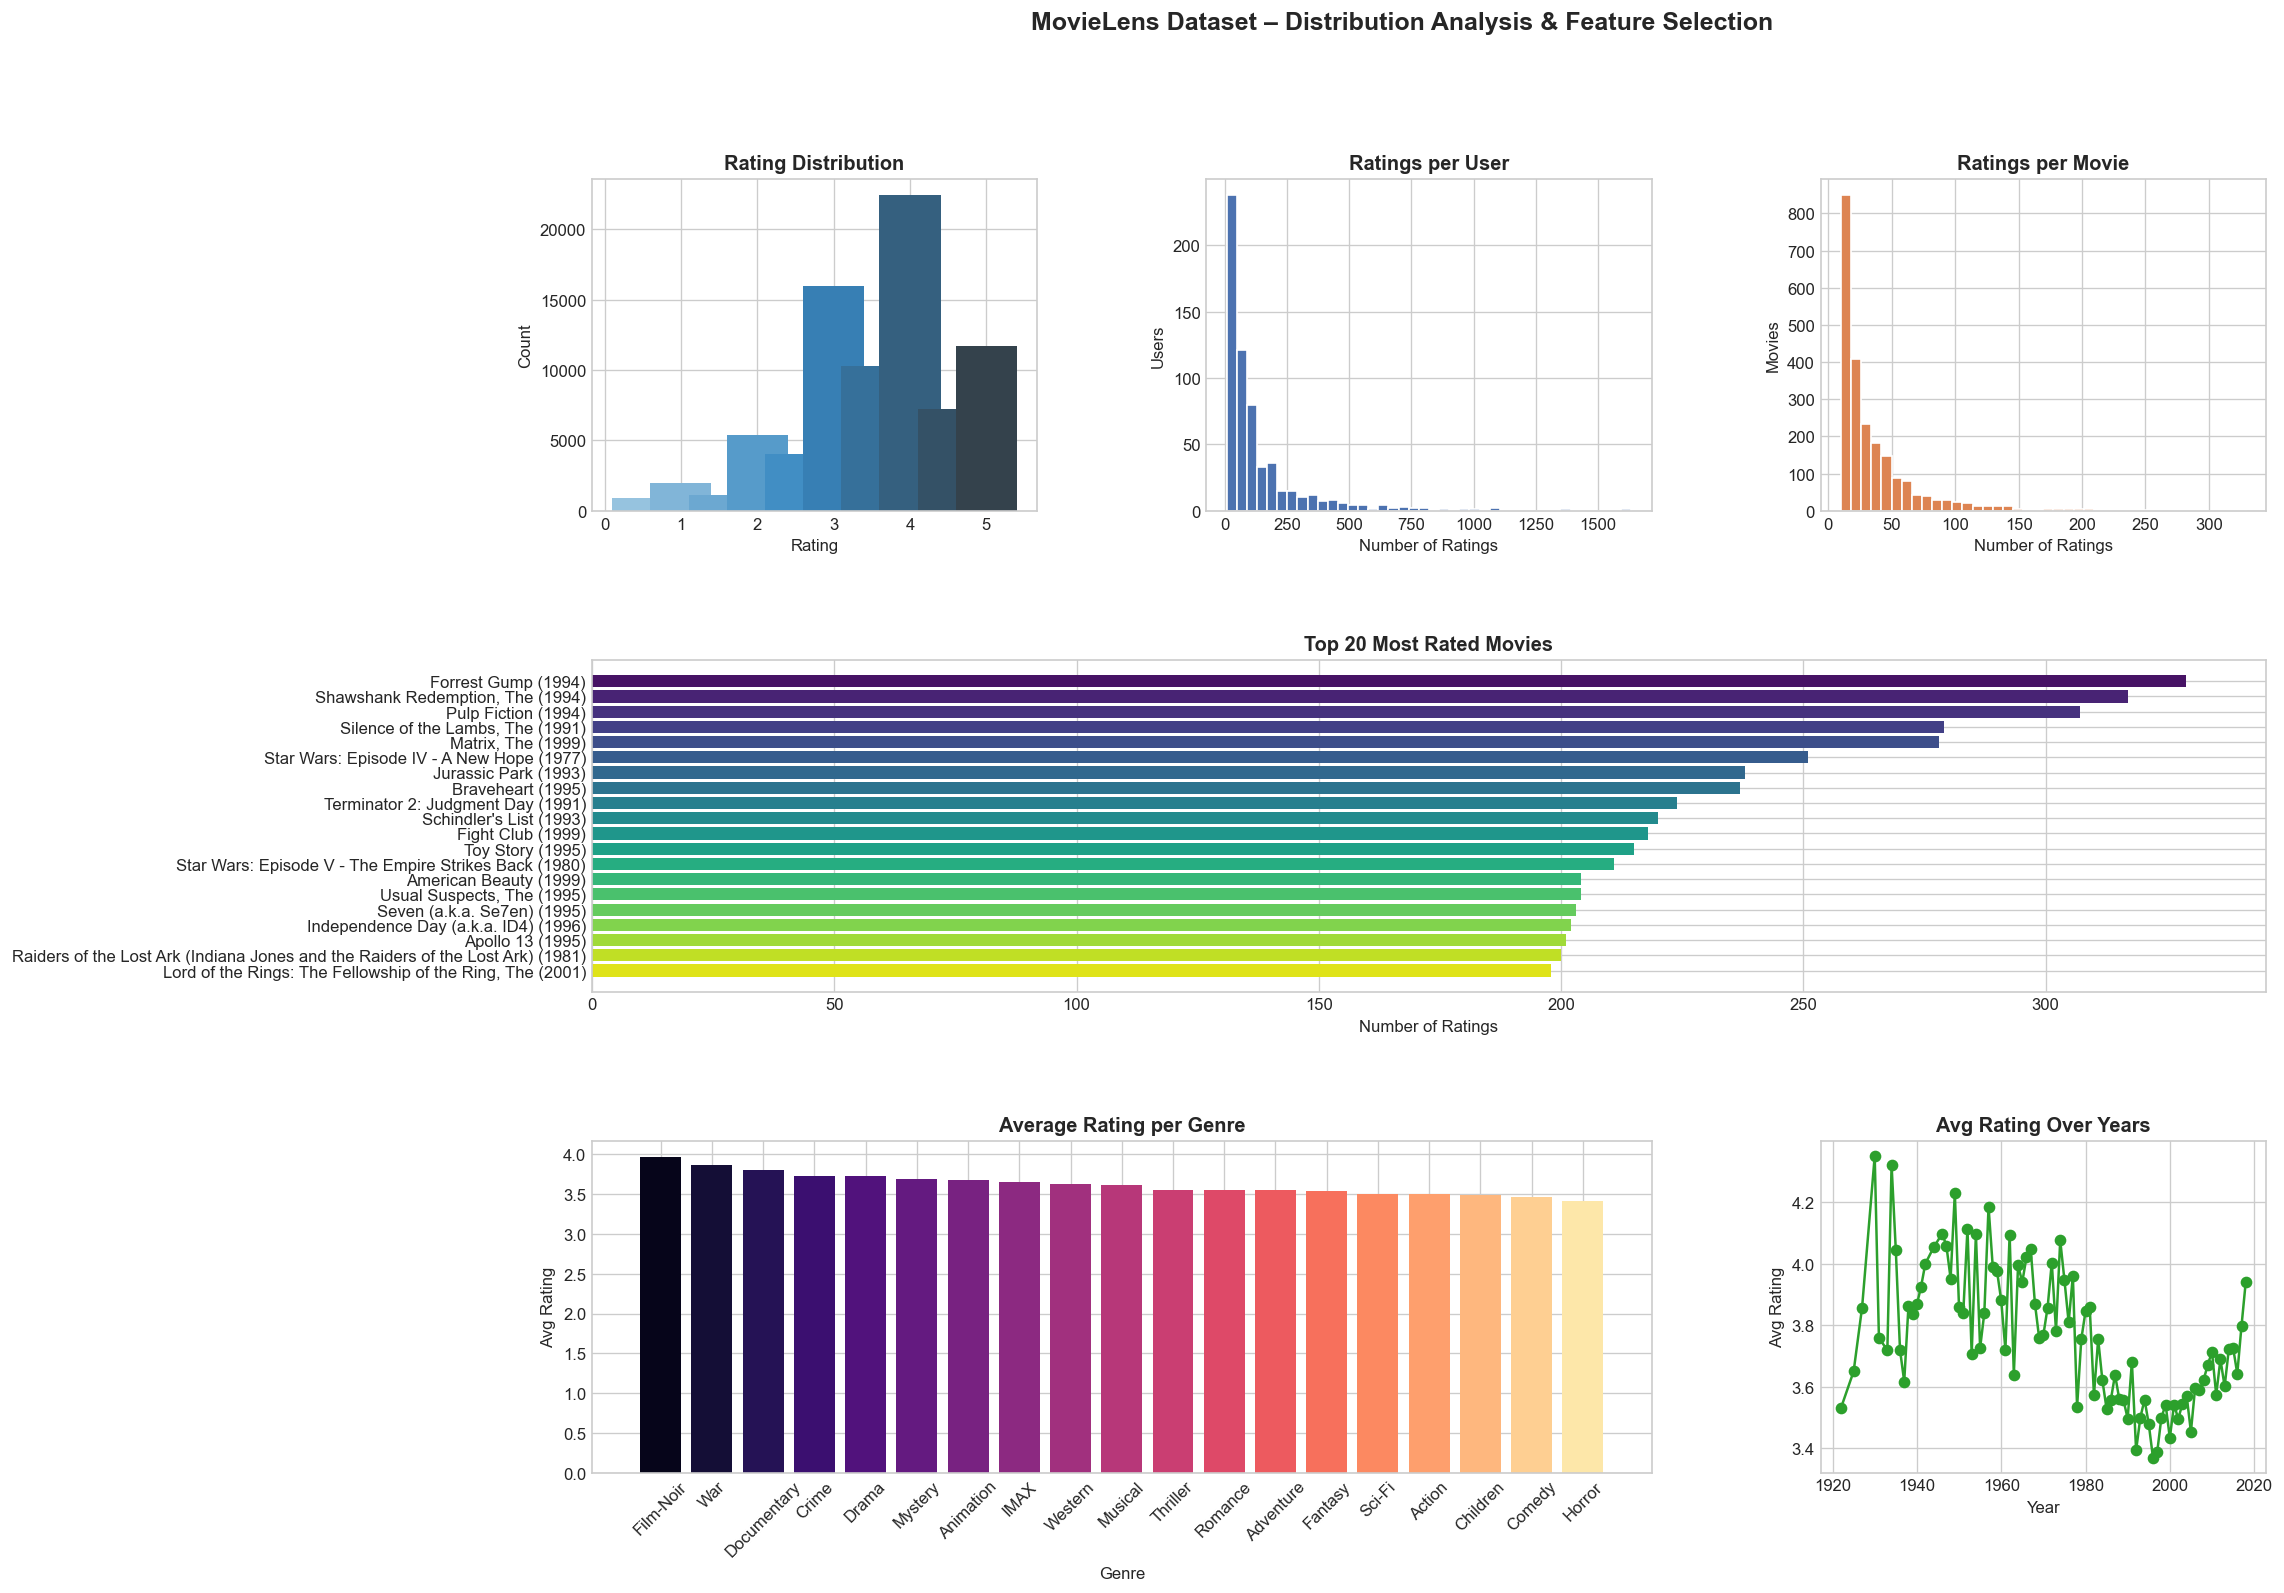

✔  Saved → distribution_analysis.png


In [21]:
# Combined Model Comparison (ACCURACY,F1,RECALL,RMSE,MAE,CMG)
fig = plt.figure(figsize=(18, 14))
fig.suptitle("MovieLens Dataset \u2013 Distribution Analysis & Feature Selection",
             fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# (a) Rating distribution
ax1 = fig.add_subplot(gs[0, 0])
rating_counts = data["rating"].value_counts().sort_index()
ax1.bar(rating_counts.index, rating_counts.values,
        color=sns.color_palette("Blues_d", len(rating_counts)))
ax1.set_title("Rating Distribution", fontweight="bold")
ax1.set_xlabel("Rating"); ax1.set_ylabel("Count")

# (b) Ratings per user
ax2 = fig.add_subplot(gs[0, 1])
user_rating_counts = data.groupby("userId").size()
ax2.hist(user_rating_counts, bins=40, color="#4C72B0", edgecolor="white")
ax2.set_title("Ratings per User", fontweight="bold")
ax2.set_xlabel("Number of Ratings"); ax2.set_ylabel("Users")

# (c) Ratings per movie
ax3 = fig.add_subplot(gs[0, 2])
movie_rating_counts = data.groupby("movieId").size()
ax3.hist(movie_rating_counts, bins=40, color="#DD8452", edgecolor="white")
ax3.set_title("Ratings per Movie", fontweight="bold")
ax3.set_xlabel("Number of Ratings"); ax3.set_ylabel("Movies")

# (d) Top-20 most rated movies
ax4 = fig.add_subplot(gs[1, :])
top20 = (data.groupby("title")["rating"]
           .count().nlargest(20).reset_index()
           .rename(columns={"rating": "count"}))
ax4.barh(top20["title"], top20["count"],
         color=sns.color_palette("viridis", 20))
ax4.set_title("Top 20 Most Rated Movies", fontweight="bold")
ax4.set_xlabel("Number of Ratings"); ax4.invert_yaxis()

# (e) Average rating per genre
ax5 = fig.add_subplot(gs[2, 0:2])
genre_df = data.copy()
genre_df["genres_split"] = genre_df["genres"].str.split("|")
genre_exploded = genre_df.explode("genres_split")
genre_avg = (genre_exploded.groupby("genres_split")["rating"]
             .mean().sort_values(ascending=False))
ax5.bar(genre_avg.index, genre_avg.values,
        color=sns.color_palette("magma", len(genre_avg)))
ax5.set_title("Average Rating per Genre", fontweight="bold")
ax5.set_xlabel("Genre"); ax5.set_ylabel("Avg Rating")
ax5.tick_params(axis="x", rotation=45)

# (f) Rating over time
ax6 = fig.add_subplot(gs[2, 2])
yearly = data.groupby("year")["rating"].mean()
ax6.plot(yearly.index, yearly.values, marker="o", color="#2ca02c")
ax6.set_title("Avg Rating Over Years", fontweight="bold")
ax6.set_xlabel("Year"); ax6.set_ylabel("Avg Rating")

plt.savefig("distribution_analysis.png", bbox_inches="tight")
plt.show()
print("\u2714  Saved \u2192 distribution_analysis.png")

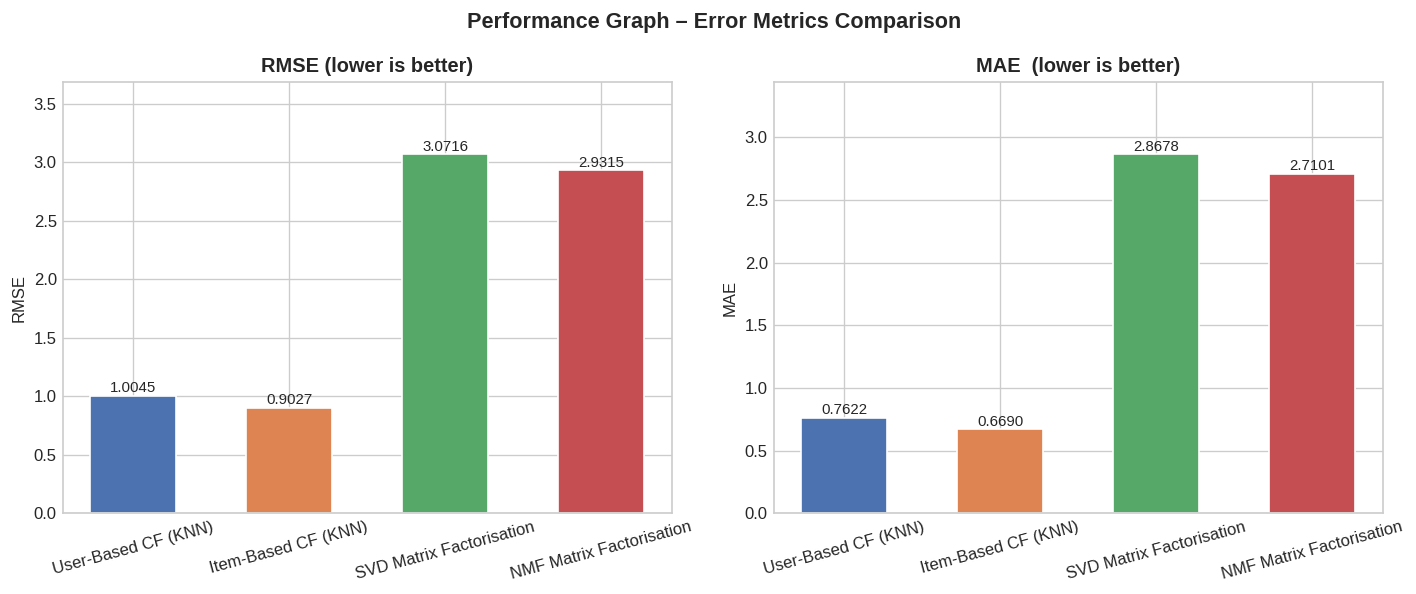

✔  Saved → performance_comparison.png


In [104]:
#  Performance Graph: Error Metrics (RMSE AND MAE)

#  Performance Graph: Error Metrics (RMSE AND MAE)
models = results_df.index.tolist()
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig2, (ax_rmse, ax_mae) = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Performance Graph – Error Metrics Comparison",
              fontsize=13, fontweight="bold")

for ax, metric, title in [
    (ax_rmse, "rmse", "RMSE (lower is better)"),
    (ax_mae,  "mae",  "MAE  (lower is better)")
]:
    vals = results_df[metric].values
    bars = ax.bar(models, vals, color=colors, edgecolor="white", width=0.55)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(metric.upper())
    ax.set_ylim(0, max(vals) * 1.2)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.003,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("performance_comparison.png", bbox_inches="tight")
plt.show()
print("✔  Saved → performance_comparison.png")

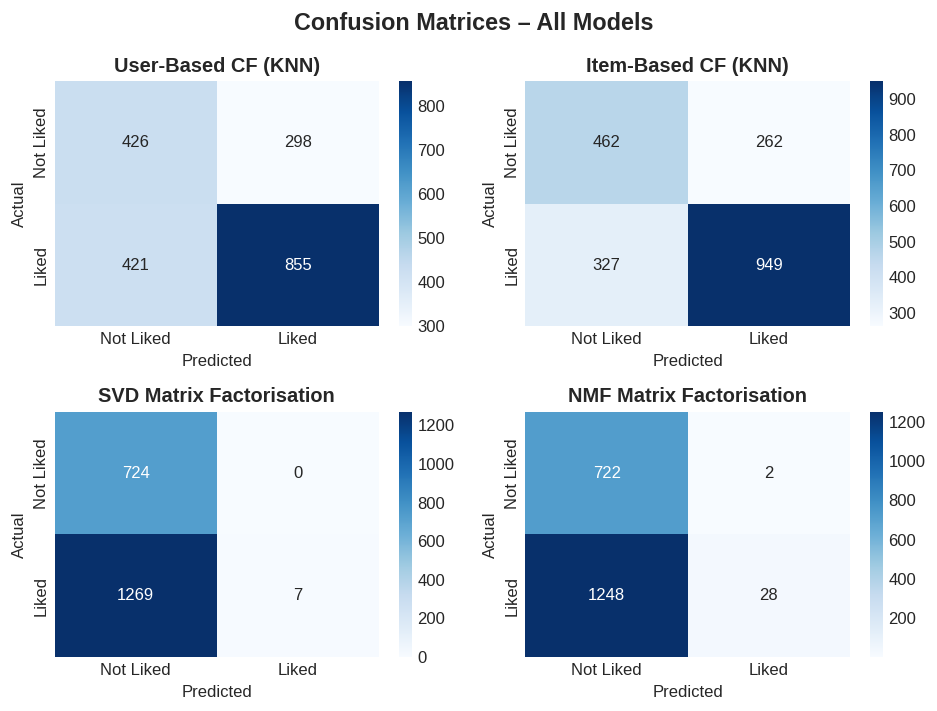

✔  Saved → confusion_matrices.png


In [105]:
# Combined Confusion Matrices (USER-BASED CF (KNN),ITEM-BASED CF (KNN),SVD MATRIX ,NMF MATRIX)
y_true_bin = to_binary(y_true_ub[:2000])

fig3, axes3 = plt.subplots(2, 2, figsize=(8, 6))
fig3.suptitle("Confusion Matrices – All Models", fontsize=14, fontweight="bold")

pred_map = {
    "User-Based CF (KNN)":       y_pred_ub,
    "Item-Based CF (KNN)":       y_pred_ib,
    "SVD Matrix Factorisation":  y_pred_svd,
    "NMF Matrix Factorisation":  y_pred_nmf,
}

for ax, (name, preds) in zip(axes3.flat, pred_map.items()):
    cm = confusion_matrix(y_true_bin, to_binary(np.clip(preds, 0.5, 5.0)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Liked", "Liked"],
                yticklabels=["Not Liked", "Liked"])
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight")
plt.show()
print("✔  Saved → confusion_matrices.png")

In [106]:
# Sample Movie Recommendations
print("="*65)
print("  SAMPLE RECOMMENDATIONS")
print("="*65)

def recommend_movies_svd(user_id_original, top_n=10):
    if user_id_original not in le_user.classes_:
        print(f"  User {user_id_original} not found in training data.")
        return
    u_idx = le_user.transform([user_id_original])[0]
    rated_movies = set(data[data["userId"] == user_id_original]["movieId"].tolist())
    scores = reconstructed_svd[u_idx]
    movie_scores = pd.DataFrame({
        "movie_idx": range(len(scores)),
        "predicted_rating": scores
    })
    movie_scores["movieId"] = le_movie.inverse_transform(movie_scores["movie_idx"])
    movie_scores = movie_scores[~movie_scores["movieId"].isin(rated_movies)]
    movie_scores = movie_scores.sort_values("predicted_rating", ascending=False).head(top_n)
    movie_scores = movie_scores.merge(movies[["movieId", "title", "genres"]], on="movieId")

    print(f"\n  Top-{top_n} Recommendations for User {user_id_original}:")
    print(f"  {'Rank':<6} {'Predicted Rating':<20} {'Title':<45} {'Genres'}")
    print("  " + "\u2500" * 110)
    for rank, (_, row) in enumerate(movie_scores.iterrows(), 1):
        title   = row["title"][:43]
        genres  = row["genres"]
        rating  = row["predicted_rating"]
        print(f"  {rank:<6} {rating:<20.3f} {title:<45} {genres}")

sample_users = data["userId"].value_counts().index[:3].tolist()
for uid in sample_users:
    recommend_movies_svd(uid, top_n=10)

  SAMPLE RECOMMENDATIONS

  Top-10 Recommendations for User 414:
  Rank   Predicted Rating     Title                                         Genres
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1      0.658                Jungle Book, The (1994)                       Adventure|Children|Romance
  2      0.580                Borat: Cultural Learnings of America for Ma   Comedy
  3      0.560                Naked Gun 33 1/3: The Final Insult (1994)     Action|Comedy
  4      0.510                All About My Mother (Todo sobre mi madre) (   Drama
  5      0.489                Longest Day, The (1962)                       Action|Drama|War
  6      0.488                Dead Man (1995)                               Drama|Mystery|Western
  7      0.452                Elite Squad (Tropa de Elite) (2007)           Action|Crime|Drama|Thriller
  8      0.437                Third Man, The (1949)                         Film-Noir|

In [107]:
#  Final Results Summary

print("="*65)
print("  FINAL RESULTS SUMMARY")
print("="*65)
print(results_df[["accuracy", "f1", "recall", "rmse", "mae"]].to_string())

best = results_df["f1"].idxmax()
print(f"\n  Best model by F1 Score \u2192 {best}")

print("\n  Output files saved:")
print("    \u2022 distribution_analysis.png")
print("    \u2022 model_comparison.png")
print("    \u2022 performance_comparison.png")
print("    \u2022 confusion_matrices.png")
print("\n  \u2714  All done.")


  FINAL RESULTS SUMMARY
                          accuracy        f1    recall      rmse       mae
model                                                                     
User-Based CF (KNN)         0.6405  0.703993  0.670063  1.004527  0.762221
Item-Based CF (KNN)         0.7055  0.763168  0.743730  0.902742  0.669015
SVD Matrix Factorisation    0.3655  0.010912  0.005486  3.071554  2.867828
NMF Matrix Factorisation    0.3750  0.042879  0.021944  2.931519  2.710099

  Best model by F1 Score → Item-Based CF (KNN)

  Output files saved:
    • distribution_analysis.png
    • model_comparison.png
    • performance_comparison.png
    • confusion_matrices.png

  ✔  All done.
